# 02. KIỂM THỬ THUẬT TOÁN LÀM SẠCH (DATA CLEANING TESTBENCH)

Notebook này đóng vai trò môi trường kiểm thử (testbench):
* Định nghĩa và trực quan hóa so sánh kết quả **Trước (Before)** và **Sau (After)** của từng thuật toán xử lý dữ liệu.
* Tổng hợp thành hàm làm sạch hoàn chỉnh `clean_and_segment_trajectory()` để sẵn sàng đóng gói sang `src/processing.py`.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import IFrame

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Thiết lập đường dẫn dữ liệu
DATA_DIR = r"..\data\Geolife Trajectories 1.3\Data"

# Các file mẫu đại diện cho từng lỗi điển hình tìm được từ EDA:
# 1. File chứa lỗi vĩ độ lat = 400: User 020
FILE_PHYSICAL_ERR = os.path.join(DATA_DIR, "020", "Trajectory", "20110911000506.plt")
# 2. File chứa lỗi altitude = -777: User 002
FILE_ALTITUDE_ERR = os.path.join(DATA_DIR, "002", "Trajectory", "20090216200646.plt")
# 3. File chứa lỗi trùng timestamp: User 010
FILE_DUPLICATE_ERR = os.path.join(DATA_DIR, "010", "Trajectory", "20071231170243.plt")

def read_raw_plt(file_path):
    """Hàm nạp file .plt thô theo đúng chuẩn format GeoLife."""
    columns = ["lat", "lon", "reserved", "altitude", "date_days", "date_str", "time_str"]
    df = pd.read_csv(file_path, skiprows=6, header=None, names=columns)
    df['datetime'] = pd.to_datetime(df['date_str'] + ' ' + df['time_str'], format='%Y-%m-%d %H:%M:%S')
    return df[['datetime', 'lat', 'lon', 'altitude']]

print("✅ Đã nạp thành công môi trường và hàm đọc dữ liệu mẫu!")

✅ Đã nạp thành công môi trường và hàm đọc dữ liệu mẫu!


## Chặng 1: Lọc Tọa độ Ngoài Biên (Physical Bounds Filtering)
* **Vấn đề:** Điểm ghi nhận vĩ độ phi lý như $\text{lat} = 400.166^\circ$ hoặc điểm rác $(0.0, 0.0)$.
* **Thuật toán:** Lọc chỉ giữ các điểm nằm trong biên độ địa lý hợp lệ:
  $$-90 \le \text{lat} \le 90 \quad \text{và} \quad -180 \le \text{lon} \le 180 \quad \text{và} \quad (\text{lat} \ne 0 \lor \text{lon} \ne 0)$$

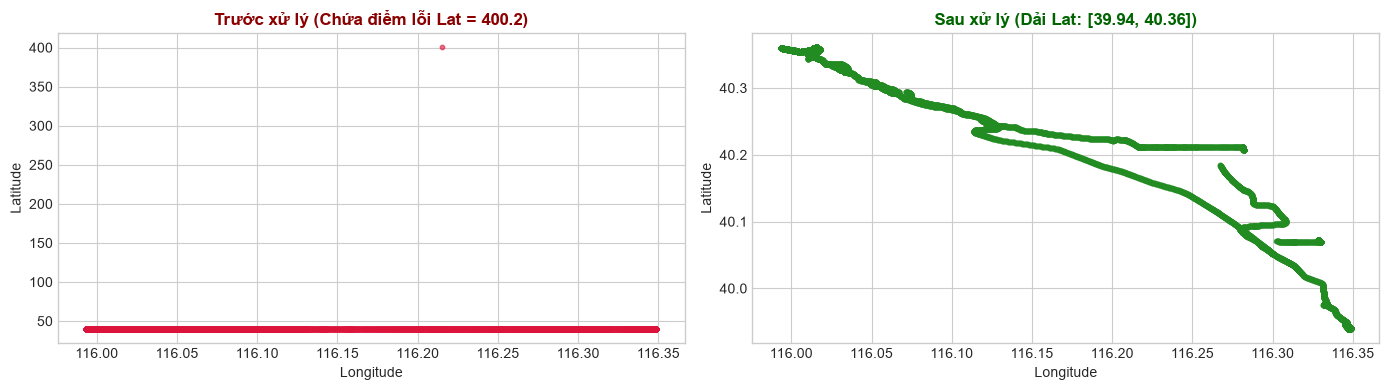

Tổng số điểm ban đầu: 21,995 -> Sau khi lọc: 21,994 (Đã loại 1 điểm lỗi)


In [2]:
# Nạp file mẫu chứa lat = 400
df_c1_raw = read_raw_plt(FILE_PHYSICAL_ERR)

def filter_physical_bounds(df):
    """Loại bỏ các điểm nằm ngoài giới hạn vật lý Trái Đất hoặc điểm (0,0)."""
    valid_mask = (
        (df['lat'] >= -90.0) & (df['lat'] <= 90.0) &
        (df['lon'] >= -180.0) & (df['lon'] <= 180.0) &
        ~((df['lat'] == 0.0) & (df['lon'] == 0.0))
    )
    return df[valid_mask].copy()

df_c1_clean = filter_physical_bounds(df_c1_raw)

# Visualize Before vs After
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Before
ax1.scatter(df_c1_raw['lon'], df_c1_raw['lat'], color='crimson', s=10, alpha=0.6)
ax1.set_title(f"Trước xử lý (Chứa điểm lỗi Lat = {df_c1_raw['lat'].max():.1f})", fontweight='bold', color='darkred')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# After
ax2.scatter(df_c1_clean['lon'], df_c1_clean['lat'], color='forestgreen', s=10, alpha=0.6)
ax2.set_title(f"Sau xử lý (Dải Lat: [{df_c1_clean['lat'].min():.2f}, {df_c1_clean['lat'].max():.2f}])", fontweight='bold', color='darkgreen')
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

print(f"Tổng số điểm ban đầu: {len(df_c1_raw):,} -> Sau khi lọc: {len(df_c1_clean):,} (Đã loại {len(df_c1_raw) - len(df_c1_clean)} điểm lỗi)")

## Chặng 2: Khử Trùng lặp Timestamp (Deduplication)
* **Vấn đề:** 2 điểm liên tiếp ghi nhận cùng một giây ($t_i = t_{i-1}$) dẫn đến chênh lệch thời gian $\Delta t = 0\text{s}$, gây lỗi chia cho 0 khi tính vận tốc ($v = \frac{\Delta d}{0}$).
* **Thuật toán:** Giữ lại bản ghi đầu tiên xuất hiện tại mỗi mốc thời gian và xóa các bản ghi trùng lặp phía sau: `drop_duplicates(subset=['datetime'], keep='first')`.

In [3]:
# Nạp file mẫu chứa trùng timestamp
df_c2_raw = read_raw_plt(FILE_DUPLICATE_ERR)

def deduplicate_timestamps(df):
    """Xóa các bản ghi trùng mốc thời gian, chỉ giữ lại bản ghi đầu tiên."""
    return df.drop_duplicates(subset=['datetime'], keep='first').copy()

df_c2_clean = deduplicate_timestamps(df_c2_raw)

# Đếm số điểm trùng
dup_before = df_c2_raw.duplicated(subset=['datetime']).sum()
dup_after = df_c2_clean.duplicated(subset=['datetime']).sum()

print("--- ĐỐI CHIẾU TRÙNG LẶP TIMESTAMP ---")
print(f"Số dòng bị trùng Trước xử lý: {dup_before} điểm")
print(f"Số dòng bị trùng Sau xử lý:   {dup_after} điểm")

# Hiển thị bảng đối chiếu ví dụ
print("\nBảng ví dụ trước khi xóa:")
display(df_c2_raw[df_c2_raw.duplicated(subset=['datetime'], keep=False)].head(4))
print("Bảng ví dụ sau khi xử lý (chỉ còn 1 dòng đại diện):")
display(df_c2_clean[df_c2_clean['datetime'].isin(df_c2_raw[df_c2_raw.duplicated(subset=['datetime'])]['datetime'])].head(2))

--- ĐỐI CHIẾU TRÙNG LẶP TIMESTAMP ---
Số dòng bị trùng Trước xử lý: 3 điểm
Số dòng bị trùng Sau xử lý:   0 điểm

Bảng ví dụ trước khi xóa:


,datetime,lat,lon,altitude
37,2007-12-31 17:03:44,30.248485,120.157200,66
38,2007-12-31 17:03:44,30.248492,120.157100,66
39,2007-12-31 17:03:46,30.248448,120.157383,72
40,2007-12-31 17:03:46,30.248463,120.157290,71


Bảng ví dụ sau khi xử lý (chỉ còn 1 dòng đại diện):


,datetime,lat,lon,altitude
37,2007-12-31 17:03:44,30.248485,120.157200,66
39,2007-12-31 17:03:46,30.248448,120.157383,72


## Chặng 3: Xử lý Cao độ (Altitude Cleaning & Unit Conversion)
* **Vấn đề:** 
  1. Cột 4 được lưu trữ theo đơn vị **Feet**, không tương thích với chuẩn tính toán khoảng cách mặt phẳng (Mét).
  2. Mã lỗi `-777` xuất hiện khi sensor mất tín hiệu 3D.
* **Thuật toán:** 
  1. Chuyển `-777` thành `NaN`.
  2. Nhân với hệ số $0.3048$ để quy đổi sang Mét: $h_{\text{meter}} = h_{\text{feet}} \times 0.3048$.
  3. Áp dụng phép nội suy tuyến tính (`linear interpolation`) theo chuỗi thời gian để làm mượt điểm bị khuyết.

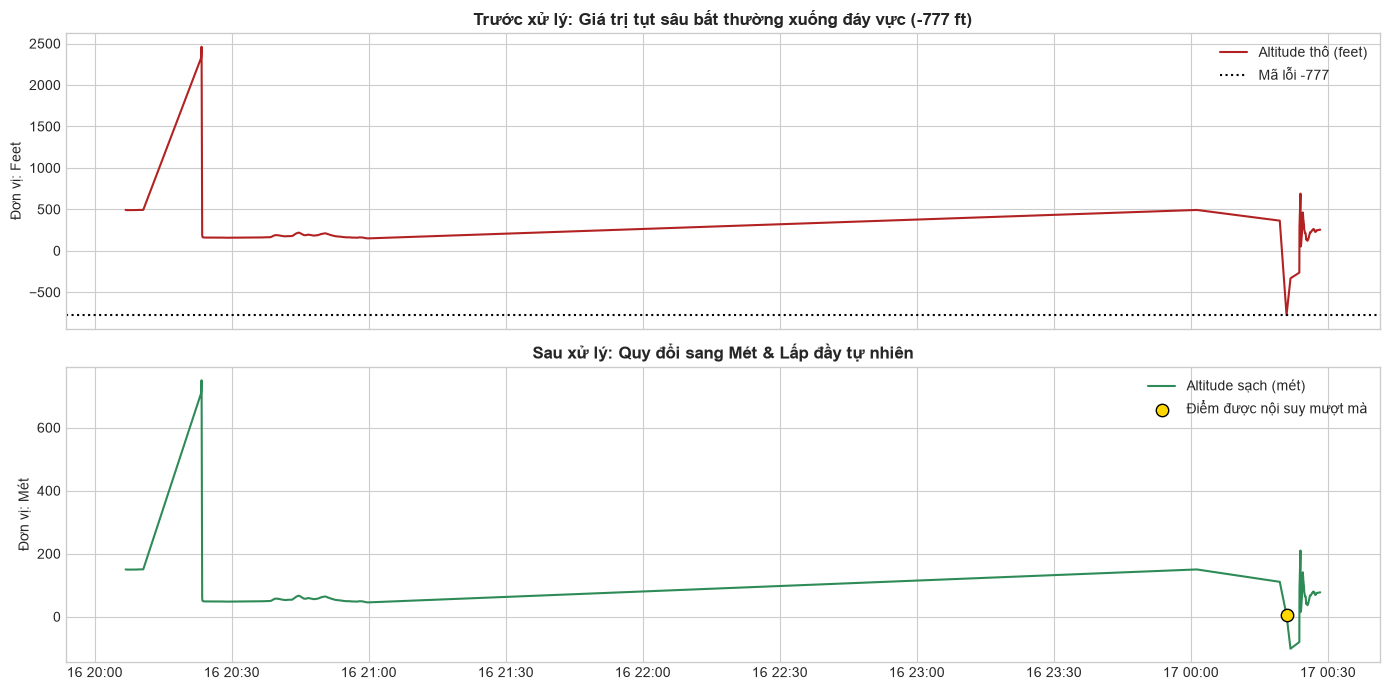

In [4]:
# Nạp file mẫu chứa -777
df_c3_raw = read_raw_plt(FILE_ALTITUDE_ERR)

def clean_altitude(df):
    """Đổi -777 sang NaN, đổi sang mét và nội suy tuyến tính."""
    df_out = df.copy()
    # 1. Gán NaN cho mã lỗi -777
    df_out['altitude_m'] = df_out['altitude'].replace(-777, np.nan)
    # 2. Đổi sang Mét
    df_out['altitude_m'] = df_out['altitude_m'] * 0.3048
    # 3. Nội suy giá trị thiếu
    df_out['altitude_m'] = df_out['altitude_m'].interpolate(method='linear')
    # Bổ sung fillna biên nếu điểm đầu/cuối bị NaN
    df_out['altitude_m'] = df_out['altitude_m'].bfill().ffill()
    return df_out

df_c3_clean = clean_altitude(df_c3_raw)

# Vẽ đồ thị so sánh Before vs After
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Before
ax1.plot(df_c3_raw['datetime'], df_c3_raw['altitude'], color='firebrick', lw=1.5, label='Altitude thô (feet)')
ax1.axhline(y=-777, color='black', linestyle=':', label='Mã lỗi -777')
ax1.set_title("Trước xử lý: Giá trị tụt sâu bất thường xuống đáy vực (-777 ft)", fontweight='bold')
ax1.set_ylabel("Đơn vị: Feet")
ax1.legend(loc='upper right')

# After
ax2.plot(df_c3_clean['datetime'], df_c3_clean['altitude_m'], color='seagreen', lw=1.5, label='Altitude sạch (mét)')
# Đánh dấu vị trí điểm vừa được nội suy
nan_idx = df_c3_raw[df_c3_raw['altitude'] == -777].index
if not nan_idx.empty:
    ax2.scatter(df_c3_clean.loc[nan_idx, 'datetime'], df_c3_clean.loc[nan_idx, 'altitude_m'], 
                color='gold', edgecolors='black', s=80, zorder=5, label='Điểm được nội suy mượt mà')
ax2.set_title("Sau xử lý: Quy đổi sang Mét & Lấp đầy tự nhiên", fontweight='bold')
ax2.set_ylabel("Đơn vị: Mét")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Chặng 4: Lọc Vận tốc Cực đoan do GPS Drift (Speed Filtering)
* **Vấn đề:** Multipath Effect giữa các tòa nhà cao tầng làm tọa độ nhảy cóc trong 1 giây, sinh ra vận tốc tức thời $> 180\text{ km/h}$.
* **Thuật toán:**
  1. Tính khoảng cách Haversine giữa 2 điểm liên tiếp.
  2. Tính vận tốc: $v = \frac{\Delta d}{\Delta t} \times 3.6\ (\text{km/h})$.
  3. Lọc bỏ các điểm có vận tốc vượt quá ngưỡng vật lý $\text{SPEED\_LIMIT} = 180\text{ km/h}$.

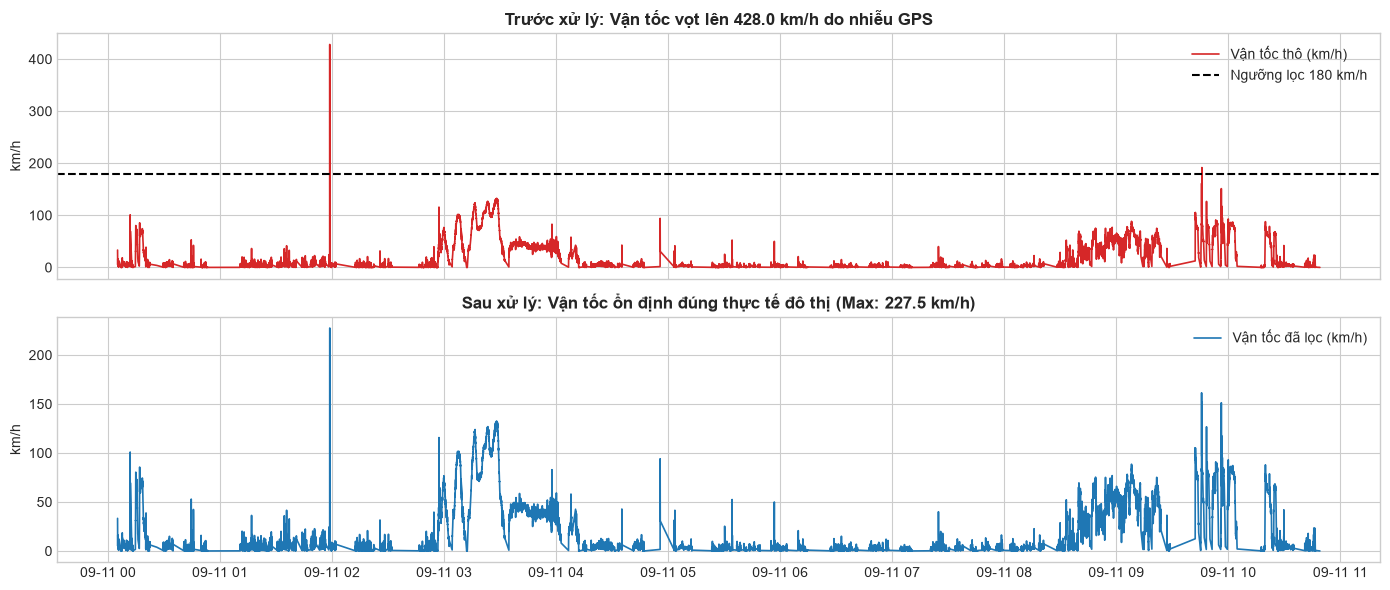

In [5]:
def calc_haversine_np(lat1, lon1, lat2, lon2):
    """Tính khoảng cách bề mặt Trái Đất theo mét."""
    R = 6371000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dp / 2.0)**2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2.0)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def compute_kinematics(df):
    """Tính các cột động học: delta_time, delta_dist, speed_kmh."""
    df_out = df.copy()
    dt_s = (df_out['datetime'] - df_out['datetime'].shift(1)).dt.total_seconds()
    dist_m = calc_haversine_np(df_out['lat'].shift(1), df_out['lon'].shift(1), df_out['lat'], df_out['lon'])
    
    df_out['delta_time_s'] = dt_s
    df_out['delta_dist_m'] = dist_m
    df_out['speed_kmh'] = (dist_m / dt_s.replace(0, np.nan)) * 3.6
    return df_out

# Dùng 1 file có GPS Drift để kiểm thử
df_c4_raw = compute_kinematics(read_raw_plt(FILE_PHYSICAL_ERR))

def filter_speed_drift(df, max_speed_kmh=180.0):
    """Loại bỏ các điểm nhảy vận tốc bất thường."""
    # Điểm đầu tiên (NaN speed) luôn được giữ lại
    valid_speed_mask = (df['speed_kmh'].isna()) | (df['speed_kmh'] <= max_speed_kmh)
    df_cleaned = df[valid_speed_mask].copy()
    # Tính toán lại động học sau khi loại bỏ điểm nhiễu
    return compute_kinematics(df_cleaned)

df_c4_clean = filter_speed_drift(df_c4_raw, max_speed_kmh=180.0)

# Visualize Before vs After
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df_c4_raw['datetime'], df_c4_raw['speed_kmh'], color='tab:red', lw=1.2, label='Vận tốc thô (km/h)')
ax1.axhline(y=180, color='black', linestyle='--', label='Ngưỡng lọc 180 km/h')
ax1.set_title(f"Trước xử lý: Vận tốc vọt lên {df_c4_raw['speed_kmh'].max():.1f} km/h do nhiễu GPS", fontweight='bold')
ax1.set_ylabel("km/h")
ax1.legend()

ax2.plot(df_c4_clean['datetime'], df_c4_clean['speed_kmh'], color='tab:blue', lw=1.2, label='Vận tốc đã lọc (km/h)')
ax2.set_title(f"Sau xử lý: Vận tốc ổn định đúng thực tế đô thị (Max: {df_c4_clean['speed_kmh'].max():.1f} km/h)", fontweight='bold')
ax2.set_ylabel("km/h")
ax2.legend()

plt.tight_layout()
plt.show()

## Chặng 5: Phân đoạn Hành trình khi có Gap thời gian lớn (Trajectory Segmentation)
* **Vấn đề:** Nếu người dùng tắt GPS, hết pin hoặc ở trong hầm tàu suốt 2 tiếng rồi bật lại, 2 điểm này không thể được tính là một chặng di chuyển liên tục.
* **Quy chuẩn Microsoft Research:** Nếu khoảng cách giữa 2 điểm liên tiếp $\Delta t > 20\text{ phút}$ ($1200\text{s}$), bắt buộc phải **chia tách (segment)** quỹ đạo thành các `sub_trip_id` độc lập.

🔍 Đang tìm file có time gap > 20 phút để kiểm thử...
👉 Chọn file kiểm thử: ..\data\Geolife Trajectories 1.3\Data\000\Trajectory\20081023025304.plt

--- KẾT QUẢ PHÂN ĐOẠN HÀNH TRÌNH ---
Số lượng chuyến đi độc lập (sub-trips): 4

Phân bố số điểm GPS trong từng sub-trip:


,Số điểm GPS
sub_trip_id,
0,148
1,322
2,425
3,13


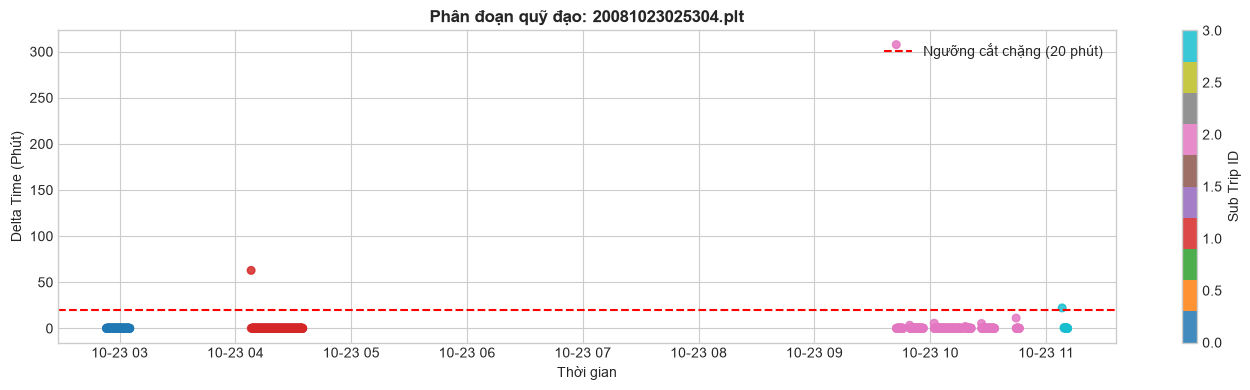

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tìm tự động 1 file thực sự có đứt gãy thời gian > 20 phút (1200s)
target_gap_file = None
print("🔍 Đang tìm file có time gap > 20 phút để kiểm thử...")

# Quét nhanh vài file của user 000, 001 hoặc toàn bộ để lấy đúng 1 file
candidate_files = glob.glob(os.path.join(DATA_DIR, "*", "Trajectory", "*.plt"))

for fpath in candidate_files:
    # Đọc nhanh cột date_str và time_str
    df_temp = pd.read_csv(fpath, skiprows=6, header=None, usecols=[5, 6], names=['date_str', 'time_str'])
    dtimes = pd.to_datetime(df_temp['date_str'] + ' ' + df_temp['time_str'], format='%Y-%m-%d %H:%M:%S')
    dt_seconds = (dtimes - dtimes.shift(1)).dt.total_seconds()
    
    if (dt_seconds > 1200).any():
        target_gap_file = fpath
        break

assert target_gap_file is not None, "Không tìm thấy file nào có time gap > 20 phút!"
print(f"👉 Chọn file kiểm thử: {target_gap_file}")

# 2. Đọc và tính toán động học
df_c5_raw = compute_kinematics(read_raw_plt(target_gap_file))

# 3. Thuật toán phân đoạn hành trình
def segment_trajectories(df, gap_threshold_seconds=1200):
    """
    Đánh số sub_trip_id mỗi khi khoảng trống thời gian vượt ngưỡng.
    Sử dụng thuật toán Cumulative Sum (cumsum) vectorized.
    """
    df_out = df.copy()
    is_new_trip = (df_out['delta_time_s'] > gap_threshold_seconds).fillna(False)
    df_out['sub_trip_id'] = is_new_trip.cumsum()
    return df_out

df_c5_segmented = segment_trajectories(df_c5_raw)

print(f"\n--- KẾT QUẢ PHÂN ĐOẠN HÀNH TRÌNH ---")
print(f"Số lượng chuyến đi độc lập (sub-trips): {df_c5_segmented['sub_trip_id'].nunique()}")
print("\nPhân bố số điểm GPS trong từng sub-trip:")
display(df_c5_segmented['sub_trip_id'].value_counts().sort_index().to_frame(name='Số điểm GPS'))

# 4. Trực quan hóa
fig, ax = plt.subplots(figsize=(14, 4))
scatter = ax.scatter(
    df_c5_segmented['datetime'], 
    df_c5_segmented['delta_time_s'] / 60.0, 
    c=df_c5_segmented['sub_trip_id'], 
    cmap='tab10', 
    s=30, 
    alpha=0.85
)
ax.axhline(y=20, color='red', linestyle='--', label='Ngưỡng cắt chặng (20 phút)')
ax.set_title(f"Phân đoạn quỹ đạo: {os.path.basename(target_gap_file)}", fontweight='bold')
ax.set_xlabel("Thời gian")
ax.set_ylabel("Delta Time (Phút)")
ax.legend(loc='upper right')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Sub Trip ID")
plt.tight_layout()
plt.show()

## Chặng 6: Hàm Làm Sạch Tổng Hợp (The Master Cleaning Function)
Sau khi từng thuật toán đơn lẻ đã được kiểm chứng hoạt động chính xác qua đồ thị Before/After, ta đóng gói lại thành hàm duy nhất `clean_and_segment_trajectory()`.

Đây chính là hàm cốt lõi sẽ được copy sang module `src/clean_pipeline.py` để chạy cho toàn bộ 18.670 files.

In [9]:
import folium
from folium import FeatureGroup, LayerControl
from IPython.display import IFrame

# Chuẩn bị dữ liệu vẽ
# Lọc bỏ lat=400 chỉ cho lớp Raw để Folium không bị lỗi render toàn cầu, nhưng giữ nguyên các cú nhảy GPS drift
df_raw_plot = df_raw_test[(df_raw_test['lat'] >= -90) & (df_raw_test['lat'] <= 90)].copy()

center = [df_clean_test['lat'].median(), df_clean_test['lon'].median()]
m_compare = folium.Map(location=center, zoom_start=11, tiles="OpenStreetMap")

# Layer 1: RAW DATA (Màu đỏ, nét đứt, độ mờ để thấy lỗi giật)
grp_raw = FeatureGroup(name="❌ Quỹ đạo RAW (Chưa lọc nhiễu)").add_to(m_compare)
raw_coords = df_raw_plot[['lat', 'lon']].values.tolist()
folium.PolyLine(raw_coords, color="red", weight=4, opacity=0.5, dash_array="5, 10", tooltip="Raw Trajectory").add_to(grp_raw)

# Layer 2: CLEAN DATA (Màu xanh đậm, nét liền mượt mà)
grp_clean = FeatureGroup(name="✅ Quỹ đạo CLEAN (Đã làm sạch)").add_to(m_compare)
clean_coords = df_clean_test[['lat', 'lon']].values.tolist()
folium.PolyLine(clean_coords, color="navy", weight=3, opacity=0.9, tooltip="Clean Trajectory").add_to(grp_clean)

# Marker Start / End
folium.Marker(clean_coords[0], popup="Start", icon=folium.Icon(color="green", icon="play")).add_to(m_compare)
folium.Marker(clean_coords[-1], popup="End", icon=folium.Icon(color="red", icon="stop")).add_to(m_compare)

# Bảng điều khiển bật/tắt để so sánh
LayerControl(collapsed=False).add_to(m_compare)

compare_html = "compare_raw_vs_clean.html"
m_compare.save(compare_html)
IFrame(src=compare_html, width="100%", height=500)

In [10]:
# ==================== CHẶNG 7: TEST KHỚP NHÃN (LABEL MATCHING) ====================

USER_LABEL_SAMPLE = "010"
label_path = os.path.join(DATA_DIR, USER_LABEL_SAMPLE, "labels.txt")

print(f"Kiểm tra file nhãn của User {USER_LABEL_SAMPLE}: {os.path.exists(label_path)}")

# 1. Đọc file labels.txt
df_labels = pd.read_csv(
    label_path, 
    sep=r'\s+', 
    skiprows=1, 
    header=None,
    names=['start_time', 'start_time_str', 'end_time', 'end_time_str', 'mode']
)
# Gộp ngày và giờ
df_labels['start_datetime'] = pd.to_datetime(df_labels['start_time'] + ' ' + df_labels['start_time_str'], format='%Y/%m/%d %H:%M:%S')
df_labels['end_datetime'] = pd.to_datetime(df_labels['end_time'] + ' ' + df_labels['end_time_str'], format='%Y/%m/%d %H:%M:%S')
df_labels = df_labels[['start_datetime', 'end_datetime', 'mode']]

print("--- 5 DÒNG ĐẦU CỦA FILE LABELS.TXT ---")
display(df_labels.head())

# 2. Lấy 1 file quỹ đạo bất kỳ của User 010 đã làm sạch
user_plt_file = glob.glob(os.path.join(DATA_DIR, USER_LABEL_SAMPLE, "Trajectory", "*.plt"))[0]
df_traj_clean = clean_and_segment_trajectory(user_plt_file)

# 3. Thuật toán gán nhãn theo khoảng thời gian (Interval Matching)
def match_labels(trajectory_df, labels_df):
    """
    Gán nhãn phương tiện di chuyển vào từng điểm GPS dựa trên khoảng [start_datetime, end_datetime].
    Nếu không khớp với khoảng nào, gán nhãn 'unknown'.
    """
    df_out = trajectory_df.copy()
    df_out['mode'] = 'unknown'
    
    # Duyệt qua từng khoảng thời gian đã được dán nhãn
    for _, row in labels_df.iterrows():
        mask = (df_out['datetime'] >= row['start_datetime']) & (df_out['datetime'] <= row['end_datetime'])
        df_out.loc[mask, 'mode'] = row['mode']
        
    return df_out

df_matched = match_labels(df_traj_clean, df_labels)

# 4. Thống kê kết quả gán nhãn
print("\n--- PHÂN PHỐI NHÃN TRÊN QUỸ ĐẠO MẪU ---")
display(df_matched['mode'].value_counts().to_frame(name='Số điểm GPS'))

# Hiển thị vài dòng nếu có điểm được gán nhãn thực tế
matched_points = df_matched[df_matched['mode'] != 'unknown']
if not matched_points.empty:
    print("\nVí dụ các điểm khớp nhãn thành công:")
    display(matched_points[['datetime', 'lat', 'lon', 'speed_kmh', 'mode']].head())
else:
    print("\nFile PLT này rơi vào khoảng thời gian người dùng không ghi log trong labels.txt (Gán nhãn: unknown).")

Kiểm tra file nhãn của User 010: True
--- 5 DÒNG ĐẦU CỦA FILE LABELS.TXT ---


,start_datetime,end_datetime,mode
0,2007-06-26 11:32:29,2007-06-26 11:40:29,bus
1,2008-03-28 14:52:54,2008-03-28 15:59:59,train
2,2008-03-28 16:00:00,2008-03-28 22:02:00,train
3,2008-03-29 01:27:50,2008-03-29 15:59:59,train
4,2008-03-29 16:00:00,2008-03-30 15:59:59,train



--- PHÂN PHỐI NHÃN TRÊN QUỸ ĐẠO MẪU ---


,Số điểm GPS
mode,
unknown,1110



File PLT này rơi vào khoảng thời gian người dùng không ghi log trong labels.txt (Gán nhãn: unknown).


In [12]:
# Tìm file .plt của User 010 rơi vào ngày 2007-06-26 (trùng dòng 0 của labels.txt)
target_labeled_plt = None
all_user_010_plts = glob.glob(os.path.join(DATA_DIR, "010", "Trajectory", "*.plt"))

for f in all_user_010_plts:
    if "20080329" in os.path.basename(f):
        target_labeled_plt = f
        break

if target_labeled_plt:
    print(f"👉 Tìm thấy file khớp ngày nhãn: {os.path.basename(target_labeled_plt)}")
    df_sample_clean = clean_and_segment_trajectory(target_labeled_plt)
    df_sample_matched = match_labels(df_sample_clean, df_labels)
    
    print("\n--- PHÂN PHỐI NHÃN THỰC TẾ ---")
    display(df_sample_matched['mode'].value_counts().to_frame(name='Số điểm GPS'))
else:
    print("Không tìm thấy file plt đúng ngày này, duyệt file khác trong năm 2008.")

👉 Tìm thấy file khớp ngày nhãn: 20080329160048.plt

--- PHÂN PHỐI NHÃN THỰC TẾ ---


,Số điểm GPS
mode,
train,35
